In [ ]:
from core_functions import *
import auxilary_functions as aux
import numpy as np
import pickle # For saving/loading data

[array([[0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0]])]


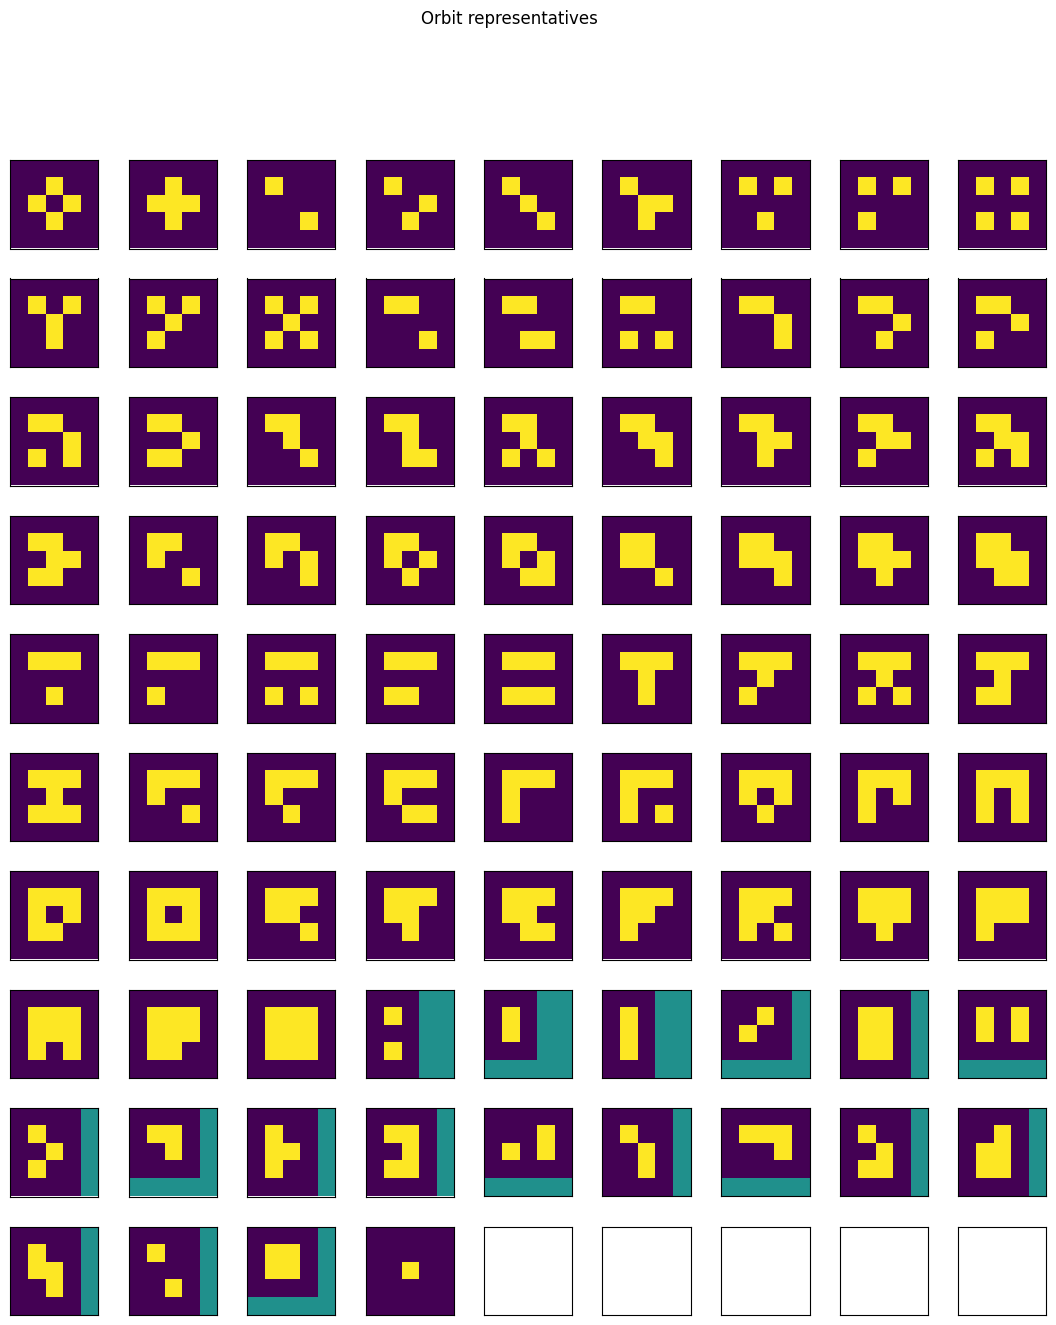

In [ ]:
# Load constituent particle configurations (orbits) for a 3x3 lattice

with open('Orbits.pickle', 'rb') as handle:
    orbits = pickle.load(handle)

print(orbits[-1]) # Note we DO NOT simulate this orbit (single isolated particle) as it has no interaction so does not contribute to the overall dynamcis
# We consider how much of the overall distribution is built from single isolated particles

##################################################################################################

# Show all orbit repersentatives

# Blue indicates sites NOT inculded in the configuration
# Yellow indicates an occupied site
# Black indicates an empty site

import math
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

# Foramtting
dims = int(math.ceil(np.sqrt(len(orbits))))

fig = plt.figure(figsize=(1.5*dims, 1.5*dims))
grid = ImageGrid(fig, 111,  # similar to subplot(111)
                    nrows_ncols=(10, 9),  # creates grid of Axes
                    axes_pad=0.3,   # pad between Axes in inch.
                    )


# what = 0
count = 0
for ax in grid:
    # Iterating over the grid returns the Axes.
    if count == len(orbits):
        break
    kernel = orbits[count][-1]
    kernel = np.select([kernel == 0], [-1], kernel)
    # kernel = np.pad(kernel, 1, 'constant', constant_values=((-1, -1), (-1, -1)))
        
    if kernel.shape != (5, 5):
        #cmap = 'CMRmap'
        #color = 'red'
        r, c = 0, 0
        B = np.zeros((5, 5))
        B[r:r+kernel.shape[0], c:c+kernel.shape[1]] = kernel
        kernel = B
    
    cax = ax.matshow(kernel)
    #cax.set_clim(0, 1)
    
    # Hide X and Y axes label marks
    ax.xaxis.set_tick_params(labelbottom=False)
    ax.yaxis.set_tick_params(labelleft=False)

    # Hide X and Y axes tick marks
    ax.set_xticks([])
    ax.set_yticks([])
    
    
    #ax.set_title(str(count), color=color)
    count += 1

# plt.savefig(f'Repersentatives.pdf', bbox_inches='tight')
fig.suptitle('Orbit representatives')
plt.show()

c:\Users\Joe\Desktop\DipolarSpin\Examples\core_functions.py:61: RuntimeWarning: invalid value encountered in scalar divide
  angle = np.arccos(displacement @ quan_axis/r)


(array([[  53.03300859,  107.33126292,  150.        ,  107.33126292,
           53.03300859],
        [ 107.33126292,  424.26406871, 1200.        ,  424.26406871,
          107.33126292],
        [ 150.        , 1200.        ,    0.        , 1200.        ,
          150.        ],
        [ 107.33126292,  424.26406871, 1200.        ,  424.26406871,
          107.33126292],
        [  53.03300859,  107.33126292,  150.        ,  107.33126292,
           53.03300859]]),
 5,
 5)

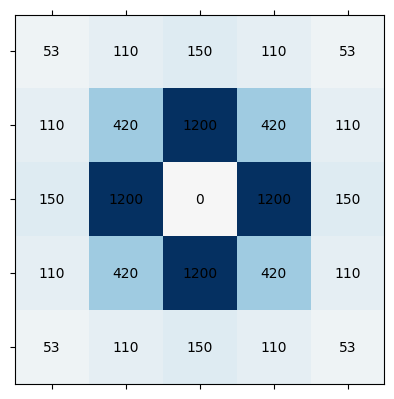

In [ ]:
# Define Ramsey measurements parameters and plot defined interaction for each particle
# Note the parameters of the larger distribution are not relavent here (e.g. the overall particle density)


# Defining 200 delay times between the pi pulses of a Ramsey sequence to simulate
# These time are evenly spaced between 0s and 350 * the duration of each pulse

intervals = 200
holds = np.linspace(0, 350 * pulse_time, intervals)

# Define the interaction strength between particles, J (Hz), the detuning of the driving field, det (Hz), and how 'stretched' the lattice is , ax/ay
J, det, ax, ay = 1500, 0, 1, 1

# Define the direction of the quantixation axis (in this case it points out of the 2D plane of particles creating an isotropic interaction) 
theta, phi = 0, 0

##################################################################################################

# Plot the interaction strength around each particle

intmatrix(5, J, xs=ax, ys=ay, theta=theta, phi=phi, plot=True)

In [ ]:
# Simulate the Ramsey measurement for each orbit

import time # For recording how long the simulations took
start_time = time.time()

orbit_dynamics = [] # To hold results

# For tracking progress
progress = 0
orbit_no = len(orbits)

for i in orbits[:-1]: # Single isolated particles do not contribute to the overall dynamcis
    config = i[-1] # Pick the repersentative of the orbit
    occ_sites = np.nonzero(config.flatten())[0] # Find which sites are occupied in the 3x3 grid (to construct the Hamiltonian)
    up_probabilities = []

    Ly, Lx = config.shape # Some orbits may be smaller then 3x3

    particles = int(np.sum(config))

    # Define the initial state of the system (all particles in the 'down' spin state)
    initial_state = np.zeros(2**particles)
    initial_state[-1] = 1
    
    # Simulate the Ramsey measurement to obtain the dynamics of the orbit
    for i in holds:
        sim_times = np.linspace(0, 2*pulse_time + i, 3) # Times which are simulated for each hold time between pi pulses (inculdes 3 times for the )

        params = [pulse_time, i, rabi_frequency] # Parameters for the pulse sequence

        # Build Hamiltonian for specific configurations/repersentative
        Hamiltonian = construct_H(particles, J, det, ax, ay, Lx, params, pulse_ramsey, theta=theta, phi=phi, Ly=Ly, occupied_sites=occ_sites)

        # Simulate the dynamics under the defined pulse sequence and extract the resulting number of 'up' spin states
        populations = Hamiltonian.evolve(initial_state, 0, sim_times)
        ups = sparse_up_prob(particles, populations)

        up_probabilities.append(ups[-1]) # Only record final state (after pulse sequence/Ramsey pulse)

    # Show progress of code
    progress += 1
    print(str(progress) + '/' + str(orbit_no) + ' Completed')
    
    # Add the overall dynamics of the orbit to the results
    orbit_dynamics.append(np.array(up_probabilities))

print("--- %s seconds ---" % (time.time() - start_time))

# Save the dynamics for every orbit (under our specific defined parameters/pulse sequence)
with open('Orbit_Ramseys.pickle', 'wb') as handle:
    pickle.dump(orbit_dynamics, handle, protocol=pickle.HIGHEST_PROTOCOL)

c:\Users\Joe\Desktop\DipolarSpin\Examples\functions.py:61: RuntimeWarning: invalid value encountered in scalar divide
  angle = np.arccos(displacement @ quan_axis/r)


1/85 Completed
2/85 Completed
3/85 Completed
4/85 Completed
5/85 Completed
6/85 Completed
7/85 Completed
8/85 Completed
9/85 Completed
10/85 Completed
11/85 Completed
12/85 Completed
13/85 Completed
14/85 Completed
15/85 Completed
16/85 Completed
17/85 Completed
18/85 Completed
19/85 Completed
20/85 Completed
21/85 Completed
22/85 Completed
23/85 Completed
24/85 Completed
25/85 Completed
26/85 Completed
27/85 Completed
28/85 Completed
29/85 Completed
30/85 Completed
31/85 Completed
32/85 Completed
33/85 Completed
34/85 Completed
35/85 Completed
36/85 Completed
37/85 Completed
38/85 Completed
39/85 Completed
40/85 Completed
41/85 Completed
42/85 Completed
43/85 Completed
44/85 Completed
45/85 Completed
46/85 Completed
47/85 Completed
48/85 Completed
49/85 Completed
50/85 Completed
51/85 Completed
52/85 Completed
53/85 Completed
54/85 Completed
55/85 Completed
56/85 Completed
57/85 Completed
58/85 Completed
59/85 Completed
60/85 Completed
61/85 Completed
62/85 Completed
63/85 Completed
6

In [ ]:
# Define density of uniform distribution to simulate
lat_filling = 0.0544

Text(0.5, 0.98, 'Sample large uniform particle distribution')

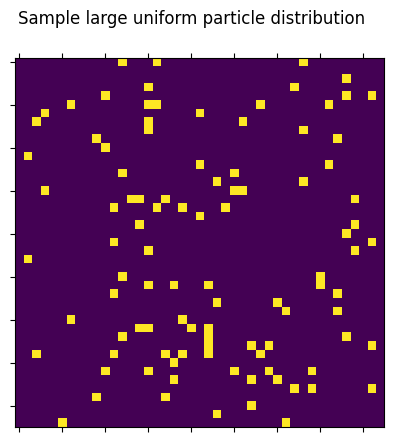

In [ ]:
# Visualize the larger uniform distribution we are going to simulate
# Sample a uniform distribution with a lattice filling of 0.0544

sample_config = aux.unif_random_config(lat_filling, 100) # (density, particles)

fig, ax = plt.subplots()

ax.xaxis.set_tick_params(labelbottom=False)
ax.yaxis.set_tick_params(labelleft=False)
ax.set_xticks([])
ax.set_yticks([])

cax = ax.matshow(sample_config)
cax.set_clim(0, 1)

fig.suptitle('Sample large uniform particle distribution')

c:\Users\Joe\Desktop\DipolarSpin\.venv\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Joe\Desktop\DipolarSpin\.venv\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 0.98, "Example orbit's Ramsey measurement")

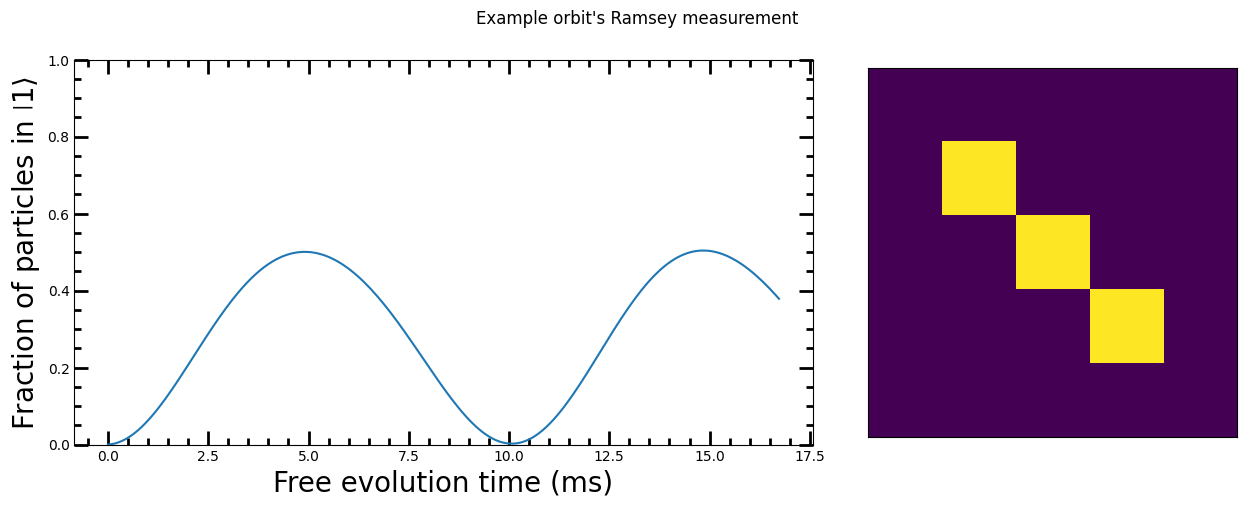

In [ ]:
# Load the Ramsey dynamics for each 3x3 particle configuration (generated above)
with open('Orbit_Ramseys.pickle', 'rb') as handle:
    orbit_dynamics = pickle.load(handle)

##################################################################################################

# Plot example Ramsey measurement for an orbit
from matplotlib import gridspec

# Pick index of example dynamics to plot
index = 4

fig = plt.figure(figsize=(15, 5))
spec = gridspec.GridSpec(ncols=2, nrows=1,
                         width_ratios=[2, 1], wspace=0.1)
axes = fig.add_subplot(spec[0])
mataxis = fig.add_subplot(spec[1])

cax = mataxis.matshow(orbits[index][-1])
cax.set_clim(0, 1)
axes.plot(holds*(10**3), orbit_dynamics[index])
axes.set_ylabel(r"Fraction of particles in $\left|1\right>$", fontsize=20)
axes.set_xlabel('Free evolution time (ms)', fontsize=20)

axes.minorticks_on()
axes.tick_params(which='major', length=10, width=2, direction='in', bottom=True, top=True, left=True, right=True)
axes.tick_params(which='minor', length=5, width=2, direction='in', bottom=True, top=True, left=True, right=True)

axes.set_ylim([0, 1])


# Hide X and Y axes label marks
mataxis.xaxis.set_tick_params(labelbottom=False)
mataxis.yaxis.set_tick_params(labelleft=False)

# Hide X and Y axes tick marks
mataxis.set_xticks([])
mataxis.set_yticks([])
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
fig.suptitle("Example orbit's Ramsey measurement")

C:\Users\Joe\AppData\Local\Temp\ipykernel_7316\2097412336.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  inset_ax = axes.inset_axes(


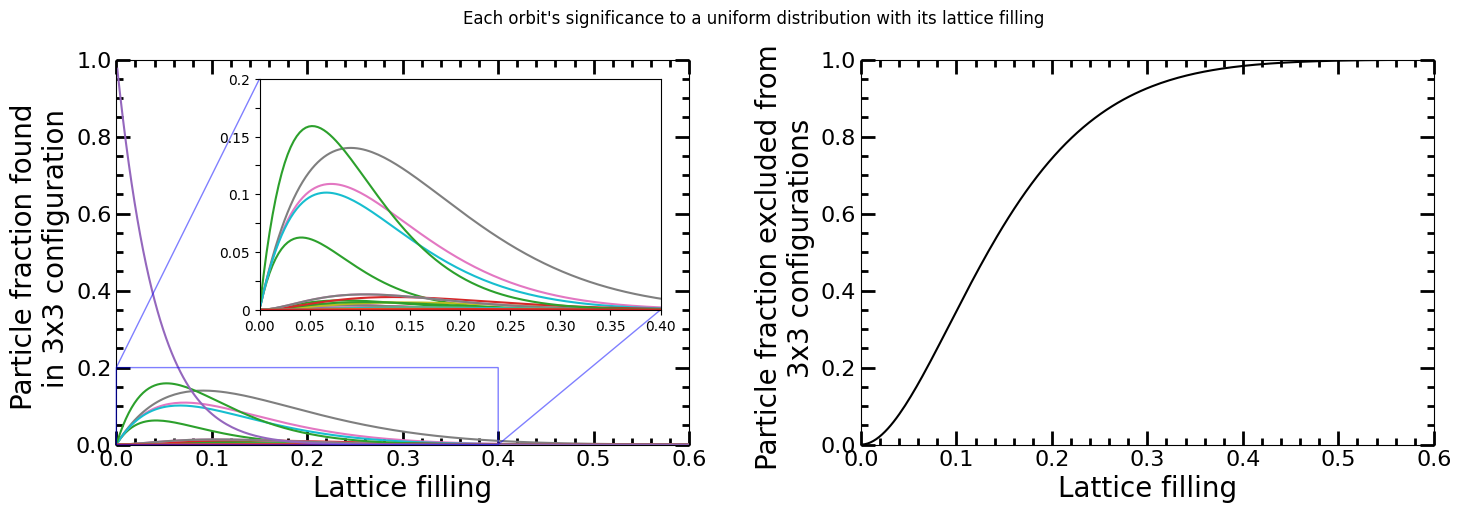

In [ ]:
# Larger distribution constituents statistics
# Show how much of the larger uniform distribution consisits of each of the 3x3 orbits

# Initializing plot

lat_fils = np.linspace(0.001, 0.6, 200)

fig = plt.figure(figsize=(17, 5))
spec = gridspec.GridSpec(ncols=2, nrows=1,
                         width_ratios=[1, 1], wspace=0.3)
axes = fig.add_subplot(spec[0])
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
ax2 = fig.add_subplot(spec[1])

inset_ax = axes.inset_axes(
   [0.25, 0.35, 0.7, 0.6],  # [x, y, width, height] w.r.t. axes
    xlim=[0, 0.4], ylim=[0, 0.2], yticklabels=[0, '', 0.05, '', 0.10, '', 0.15, '', 0.20] # sets viewport &amp; tells relation to main axes
    )

# Calculate the statistics for each orbit

leftover = np.ones(200)

for geometry in orbits: 
    # Extract relavent parameters from a repersentative of the orbit
    symm = len(geometry)
    particles = geometry[0].sum()
    fy, fx = geometry[0].shape
    empty = fy*fx - particles
    
    # Generate model for each orbit and calculate the proportion of the distribution built by the orbit for each lattice filling/desity
    pro = gen_poly(symm, particles, empty)
    prob_data = pro(lat_fils)
    
    axes.plot(lat_fils, prob_data)
    if particles != 1: # Exclude isolated particle statistics from inset
        inset_ax.plot(lat_fils, prob_data)
        

    # Calculates the proportion of the distribution unaccounted for in this model
    leftover = leftover - prob_data

# Plotting data and formatting

axes.indicate_inset_zoom(inset_ax, edgecolor='blue')
ax2.plot(lat_fils, leftover, color = 'black', label='Uncounted Particles')
# ax2.legend()
axes.set_xlabel(r"Lattice filling", fontsize=20)
ax2.set_xlabel(r"Lattice filling", fontsize=20)
axes.set_ylabel('Particle fraction found \n in 3x3 configuration', fontsize=20)

ax2.set_ylabel('Particle fraction excluded from \n 3x3 configurations', fontsize=20)

axes.minorticks_on()
axes.tick_params(which='major', length=10, width=2, direction='in', bottom=True, top=True, left=True, right=True)
axes.tick_params(which='minor', length=5, width=2, direction='in', bottom=True, top=True, left=True, right=True)

ax2.minorticks_on()
ax2.tick_params(which='major', length=10, width=2, direction='in', bottom=True, top=True, left=True, right=True)
ax2.tick_params(which='minor', length=5, width=2, direction='in', bottom=True, top=True, left=True, right=True)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
axes.set_ylim([0, 1])
ax2.set_ylim([0, 1])
axes.set_xlim([0, 0.6])
ax2.set_xlim([0, 0.6])
#plt.savefig(f'LEFTOVERS.pdf', bbox_inches='tight')
fig.suptitle("Each orbit's significance to a uniform distribution with its lattice filling")
plt.show(block=False)

The particle configurations with the highest contribution to the dynamics are printed below:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
[[0 0 0 0 0]
 [0 1 0 1 0]
 [0 0 0 0 0]]
[[0 0 0 0]
 [0 1 1 0]
 [0 0 0 0]]
[[0 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 0]]
[[0 0 0 0 0]
 [0 1 0 0 0]
 [0 0 0 1 0]
 [0 0 0 0 0]]


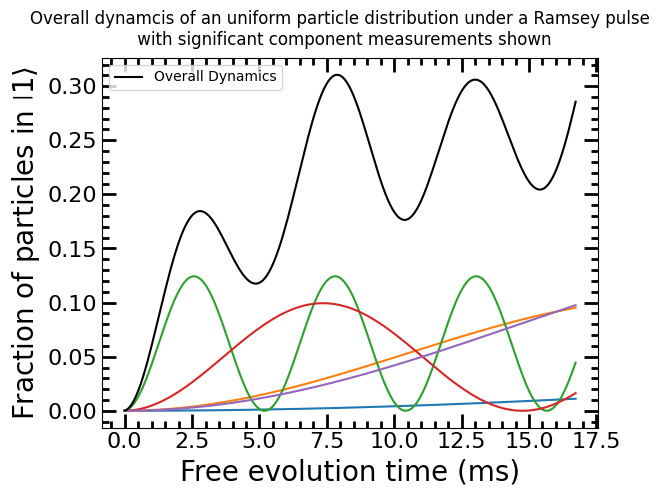

In [ ]:
##################################################################################################
fig, axes = plt.subplots(1, 1)
##################################################################################################
print('The particle configurations with the highest contribution to the dynamics are printed below:')

axes.set_ylabel(r"Fraction of particles in $\left|1\right>$", fontsize=20)
axes.set_xlabel('Free evolution time (ms)', fontsize=20)

overall_dynamics = np.zeros(intervals)
for i, n in zip(orbits[:-1] , orbit_dynamics):
    
    symm = len(i) # Number of particle configurations in this orbit (effects the proportion of the distribution consisting by the orbit)
    particles = i[0].sum() # Number of particles in each member of the orbit
    h, o = i[0].shape # Dimensions of each orbit memeber (3x3 or less)
    empty_sites = h*o - particles
    
    # Model the proportion of the uniform distribution which is built from members of the orbit for each density
    model = gen_poly(symm, particles, empty_sites)
    coef = model(lat_filling)


    ##################################################################################################
    # Plot significant contributing component Ramsey measurements and print a member of the corresponding orbit
    if coef >= 0.05:
        axes.plot(holds*(10**3), coef*np.array(n))
        print(i[0])
    ##################################################################################################


    # Add the weighted dynamics of the orbit to the final result for the overall dynamics for the large distribution
    overall_dynamics = overall_dynamics + coef*np.array(n)


##################################################################################################
# Format the final plot
axes.plot(holds*(10**3), overall_dynamics, color='black', label='Overall Dynamics')

axes.minorticks_on()
axes.tick_params(which='major', length=10, width=2, direction='in', bottom=True, top=True, left=True, right=True)
axes.tick_params(which='minor', length=5, width=2, direction='in', bottom=True, top=True, left=True, right=True)
yticks = np.linspace(0, 0.35, 8)
#axes.set_yticks(yticks) 
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
plt.savefig(f'Consitiuent_Method_Particle_Ramsey_{J}Hz_{lat_filling}_filling.png', bbox_inches='tight')
axes.legend()

fig.suptitle('Overall dynamcis of an uniform particle distribution under a Ramsey pulse \n with significant component measurements shown')
plt.show(block=False)
##################################################################################################